# Random Forest From Scratch — Fashion-MNIST Dataset

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
np.random.seed(42)

## Loading the Dataset

In [2]:
df = pd.read_csv("fashion-mnist_train.csv")

df = df.iloc[:3000].copy()

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (3000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data Exploration

In [3]:
df.shape

(3000, 785)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Columns: 785 entries, label to pixel784
dtypes: float64(700), int64(85)
memory usage: 18.0 MB


In [5]:
df.sample(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
1801,0,0,0,0,0,0,1,1,0,0,...,45.0,47.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1190,6,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,106.0,27.0,0.0,0.0,0.0,0.0,0.0
1817,6,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
251,4,0,0,0,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,101.0,149.0,171.0,36.0,0.0,0.0
2505,1,0,0,0,0,0,0,0,10,129,...,128.0,119.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data Preprocessing

**Checking for missing values**

In [6]:
df.isnull().values.any()

np.False_

**Handling missing values (if any were found above)**

In [7]:
if df.isnull().values.any():
    before = df.shape[0]
    df = df.dropna()
    print(f"Removed {before - df.shape[0]} rows containing missing values.")
    print(f"New shape: {df.shape}")
else:
    print("No missing values found. No action needed.")

No missing values found. No action needed.


**Checking for duplicate rows**

In [8]:
df.duplicated().sum()

np.int64(0)

**Handling duplicate rows

In [9]:
n_duplicates = df.duplicated().sum()

if n_duplicates > 0:
    before = df.shape[0]
    df = df.drop_duplicates()
    print(f"Removed {before - df.shape[0]} duplicate rows.")
    print(f"New shape: {df.shape}")
else:
    print("No duplicate rows found. No action needed.")

No duplicate rows found. No action needed.


**Checking for dead (zero-variance) pixel columns**

Some pixel positions (e.g. image corners) are black across every sample and carry no information.

In [10]:
feature_variances = df.drop(columns=['label']).var()
zero_var_cols = feature_variances[feature_variances < 1e-5].index

print(f"Found {len(zero_var_cols)} zero-variance (dead) columns.")

Found 0 zero-variance (dead) columns.


**Dropping the dead columns (if any were found above)**

In [11]:
if len(zero_var_cols) > 0:
    df = df.drop(columns=zero_var_cols)
    print(f"Dropped {len(zero_var_cols)} dead column(s). New shape: {df.shape}")
else:
    print("No dead columns found. No action needed.")

No dead columns found. No action needed.


**Separating features and target**

In [12]:
x = df.drop(columns=['label'])
y = df['label']

In [13]:
x.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,5,0,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,1,2,0,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
y.value_counts()

,count
label,
7,322
0,314
4,310
1,303
9,302
2,302
3,298
6,289
8,287


## Data Analysis

**Target class distribution**

/tmp/ipykernel_1776/2434255507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='tab10')


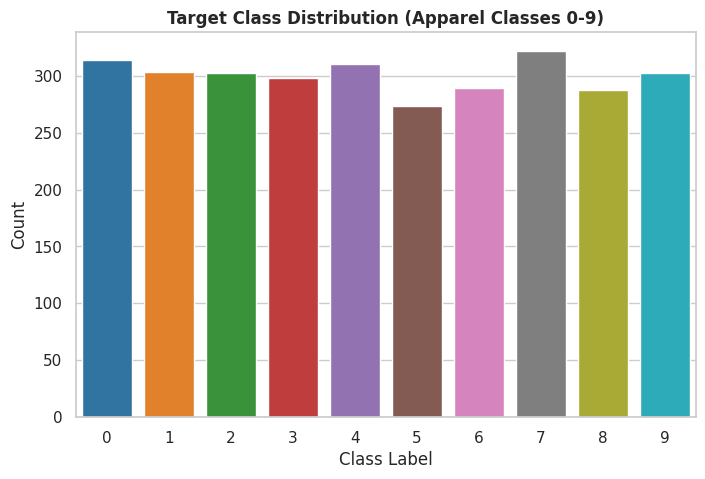

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='tab10')
plt.title('Target Class Distribution (Apparel Classes 0-9)', fontweight='bold')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

**Feature importance via Mutual Information**

Ranks each pixel by how much information it carries about the class label.

In [16]:
mutual_info = mutual_info_classif(x, y, random_state=42)
mutual_info = pd.Series(mutual_info, index=x.columns)
mutual_info.sort_values(ascending=False).head(20)

,0
pixel95,0.574364
pixel124,0.554082
pixel179,0.550921
pixel180,0.546202
pixel235,0.545515
pixel152,0.542780
pixel151,0.540871
pixel96,0.540327
pixel125,0.538558
pixel41,0.531514


**Selecting the most informative pixels (SelectKBest)**

784 raw pixel columns is a lot for a from-scratch model, so we keep only the top 100 most informative ones.

In [17]:
selector = SelectKBest(mutual_info_classif, k=100)
x_selected = selector.fit_transform(x, y)

selected_features = x.columns[selector.get_support()]
x_new = x[selected_features]

print(f"Reduced feature set shape: {x_new.shape}")

Reduced feature set shape: (3000, 100)


## Train / Test Split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)

In [19]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2400, 100)
(600, 100)
(2400,)
(600,)


## Feature Scaling (Min-Max Normalization)

Pixel values range from 0-255, so we scale them into [0, 1] using min/max statistics learned from the training set only.

In [20]:
x_train = x_train.values.astype(float)
x_test = x_test.values.astype(float)

x_min = np.min(x_train, axis=0)
x_max = np.max(x_train, axis=0)

# Prevent division by zero for columns with a flat min/max
x_max[x_max == x_min] = x_min[x_max == x_min] + 1e-8

x_train = (x_train - x_min) / (x_max - x_min)
x_test = (x_test - x_min) / (x_max - x_min)

In [21]:
x_train[:5]

array([[0.31764706, 0.20392157, 0.84705882, 0.70588235, 0.58431373,
        0.67843137, 0.78039216, 0.3372549 , 0.20392157, 0.18823529,
        0.09411765, 0.0745098 , 0.68627451, 0.94901961, 0.66666667,
        0.15686275, 0.16862745, 0.16862745, 0.16862745, 0.0627451 ,
        0.        , 0.        , 0.        , 0.12941176, 0.15686275,
        0.15686275, 0.14901961, 0.15686275, 0.16862745, 0.15686275,
        0.15686275, 0.12156863, 0.14901961, 0.14901961, 0.21568627,
        0.14901961, 0.15686275, 0.14117647, 0.14901961, 0.14901961,
        0.14901961, 0.15686275, 0.14117647, 0.31764706, 0.18823529,
        0.12156863, 0.16862745, 0.14901961, 0.12941176, 0.10196078,
        0.12941176, 0.12941176, 0.28235294, 0.19607843, 0.10196078,
        0.10980392, 0.16862745, 0.12941176, 0.12156863, 0.24313725,
        0.27058824, 0.14901961, 0.18823529, 0.21568627, 0.17647059,
        0.16862745, 0.61960784, 0.19607843, 0.12941176, 0.29803922,
        0.23529412, 0.19607843, 0.77254902, 0.76

**Converting labels to arrays**

In [22]:
y_train = np.array(y_train)
y_test = np.array(y_test)

## Random Forest — Implemented From Scratch

A single decision tree splits samples by minimizing Gini impurity, using only a random subset of features at each node.

In [23]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

In [24]:
class DecisionTreeFromScratch:
    def __init__(self, min_samples_split=2, max_depth=10, max_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        if depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Feature subspace sampling (the Random Forest ingredient):
        # evaluate only a random subset of features instead of all of them
        feat_idxs = np.random.choice(n_features, self.max_features, replace=False)

        best_feature, best_threshold = self._best_split(X, y, feat_idxs)

        if best_feature is None:
            return Node(value=self._most_common_label(y))

        left_idxs, right_idxs = self._split(X[:, best_feature], best_threshold)
        left_child = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right_child = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None
        parent_gini = self._gini(y)

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            # Subsample thresholds if a feature has too many unique values, for speed
            if len(thresholds) > 10:
                thresholds = np.random.choice(thresholds, 10, replace=False)

            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold, parent_gini)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = threshold

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold, parent_gini):
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        gini_l, gini_r = self._gini(y[left_idxs]), self._gini(y[right_idxs])
        child_gini = (n_l / n) * gini_l + (n_r / n) * gini_r

        return parent_gini - child_gini

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _gini(self, y):
        hist = np.bincount(y)
        probabilities = hist / len(y)
        return 1.0 - np.sum(probabilities ** 2)

    def _most_common_label(self, y):
        return np.bincount(y).argmax()

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

The forest builds many trees, each on a bootstrapped sample of the data, and predicts by majority vote across all trees.

In [25]:
class RandomForestFromScratch:
    def __init__(self, n_trees=10, max_depth=8, min_samples_split=2):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples, n_features = X.shape
        max_features = int(np.sqrt(n_features))

        print(f"Training Random Forest with {self.n_trees} trees...")
        print(f"Subspace sampling: evaluating {max_features} random features out of {n_features} per split.")

        for i in range(self.n_trees):
            # Bootstrap sampling: random rows, with replacement
            bootstrap_idxs = np.random.choice(n_samples, n_samples, replace=True)
            X_bootstrap = X[bootstrap_idxs]
            y_bootstrap = y[bootstrap_idxs]

            tree = DecisionTreeFromScratch(
                min_samples_split=self.min_samples_split,
                max_depth=self.max_depth,
                max_features=max_features
            )
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)

            print(f"  [Tree {i + 1}/{self.n_trees}] built on bootstrapped sample ({len(X_bootstrap)} rows)")

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(tree_preds, 0, 1)

        final_preds = [np.bincount(sample_preds).argmax() for sample_preds in tree_preds]
        return np.array(final_preds)

## Training the Model

In [26]:
rf = RandomForestFromScratch(n_trees=15, max_depth=8)
rf.fit(x_train, y_train)

Training Random Forest with 15 trees...
Subspace sampling: evaluating 10 random features out of 100 per split.
  [Tree 1/15] built on bootstrapped sample (2400 rows)
  [Tree 2/15] built on bootstrapped sample (2400 rows)
  [Tree 3/15] built on bootstrapped sample (2400 rows)
  [Tree 4/15] built on bootstrapped sample (2400 rows)
  [Tree 5/15] built on bootstrapped sample (2400 rows)
  [Tree 6/15] built on bootstrapped sample (2400 rows)
  [Tree 7/15] built on bootstrapped sample (2400 rows)
  [Tree 8/15] built on bootstrapped sample (2400 rows)
  [Tree 9/15] built on bootstrapped sample (2400 rows)
  [Tree 10/15] built on bootstrapped sample (2400 rows)
  [Tree 11/15] built on bootstrapped sample (2400 rows)
  [Tree 12/15] built on bootstrapped sample (2400 rows)
  [Tree 13/15] built on bootstrapped sample (2400 rows)
  [Tree 14/15] built on bootstrapped sample (2400 rows)
  [Tree 15/15] built on bootstrapped sample (2400 rows)


## Model Evaluation

In [27]:
y_pred = rf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", class_report)

Accuracy: 0.6833
F1 Score: 0.6726

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.82      0.72        61
           1       0.75      0.82      0.79        56
           2       0.52      0.72      0.60        60
           3       0.60      0.65      0.62        54
           4       0.60      0.40      0.48        72
           5       0.82      0.68      0.75        60
           6       0.48      0.26      0.34        54
           7       0.71      0.86      0.78        71
           8       0.92      0.90      0.91        50
           9       0.78      0.74      0.76        62

    accuracy                           0.68       600
   macro avg       0.68      0.69      0.67       600
weighted avg       0.68      0.68      0.67       600



## Visualization

**Confusion matrix**

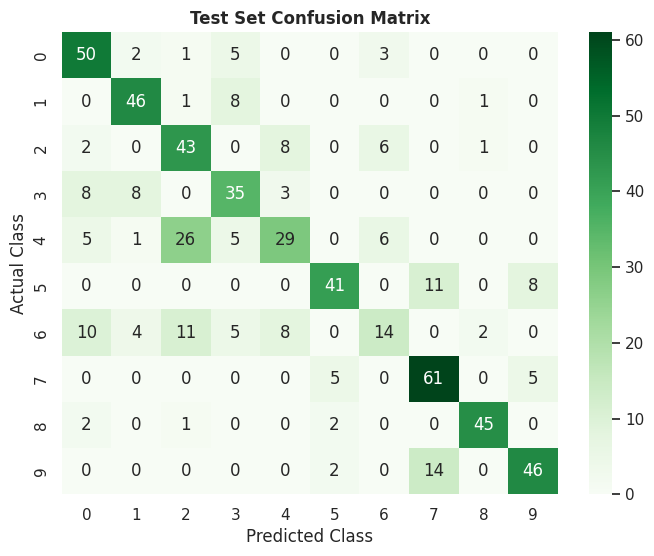

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title('Test Set Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

**Tree voting consensus**

For each test sample, how many of the 15 trees agreed with the forest's final prediction?

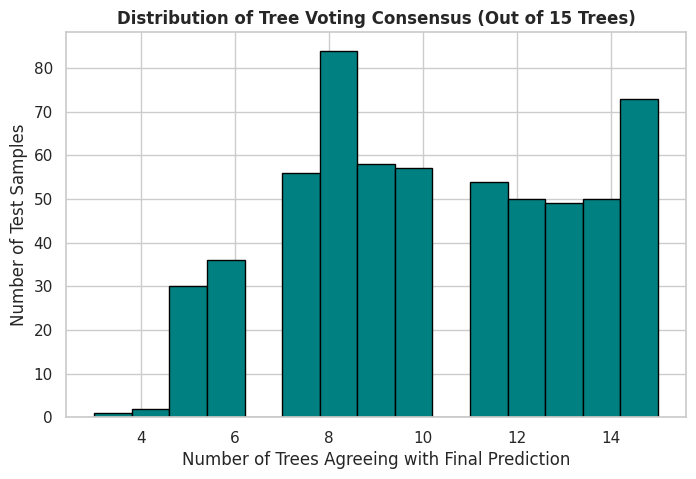

In [29]:
tree_preds = np.array([tree.predict(x_test) for tree in rf.trees])
tree_preds = np.swapaxes(tree_preds, 0, 1)

agreement_counts = [
    np.sum(sample_preds == final_pred)
    for sample_preds, final_pred in zip(tree_preds, y_pred)
]

plt.figure(figsize=(8, 5))
plt.hist(agreement_counts, bins=15, color='teal', edgecolor='black')
plt.title(f'Distribution of Tree Voting Consensus (Out of {rf.n_trees} Trees)', fontweight='bold')
plt.xlabel('Number of Trees Agreeing with Final Prediction')
plt.ylabel('Number of Test Samples')
plt.show()